# Delivery Performance Analysis
Analysis of delivery times and delays using the Olist e-commerce dataset.

## 1. Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Load data

In [3]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")

## 3. Explore orders dataset

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [7]:
len(orders)

99441

## 4. Prepare date columns

In [9]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"], errors="coerce"
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"], errors="coerce"
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"], errors="coerce"
)

In [10]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

## 5. Delivery Time Calculation

To analyse delivery performance, we calculate the number of days between the purchase date and the delivery date.

In [12]:
orders["delivery_time_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days

In [13]:
orders["delivery_time_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time_days, dtype: float64

<Axes: >

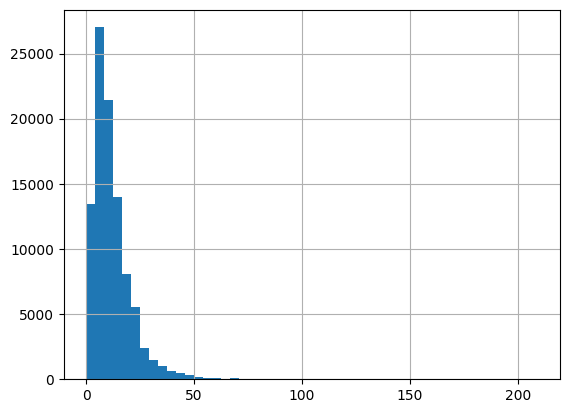

In [14]:
orders["delivery_time_days"].hist(bins=50)

<Axes: >

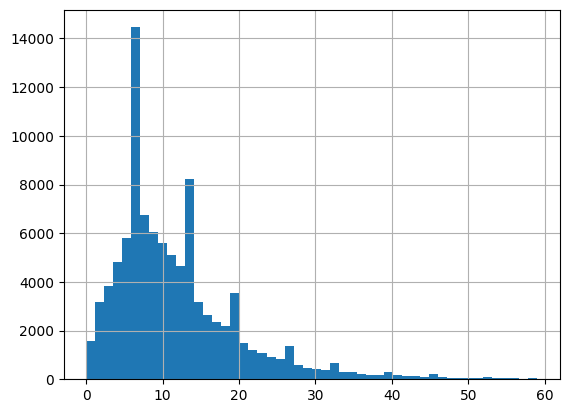

In [15]:
orders[orders["delivery_time_days"] < 60]["delivery_time_days"].hist(bins=50)

### Distribution of delivery time

Most orders are delivered within 5–15 days, with a peak around 8–10 days.

The distribution is right-skewed, meaning that while most deliveries are relatively fast, a small number of orders experience significantly longer delivery times.

In [23]:
more_than_60_days = orders[orders["delivery_time_days"] > 60]

In [24]:
more_than_60_days.shape

(288, 9)

### Extremely long deliveries

There are 288 orders with delivery times longer than 60 days.
This represents a very small fraction of the dataset, suggesting these are likely outliers or exceptional delivery cases.

In [25]:
more_than_60_days["delivery_time_days"].describe()

count    288.00000
mean      87.93750
std       34.78039
min       61.00000
25%       66.00000
50%       73.00000
75%       94.50000
max      209.00000
Name: delivery_time_days, dtype: float64

In [22]:
orders.sort_values("delivery_time_days", ascending=False).head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days
19590,ca07593549f1816d26a572e06dc1eab6,75683a92331068e2d281b11a7866ba44,delivered,2017-02-21 23:31:27,2017-02-23 02:35:15,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22,209.0
55619,1b3190b2dfa9d789e1f14c05b647a14a,d306426abe5fca15e54b645e4462dc7b,delivered,2018-02-23 14:57:35,2018-02-23 15:16:14,2018-02-26 18:49:07,2018-09-19 23:24:07,2018-03-15,208.0
61610,440d0d17af552815d15a9e41abe49359,7815125148cfa1e8c7fee1ff7974f16c,delivered,2017-03-07 23:59:51,2017-03-09 01:11:33,2017-03-15 13:00:08,2017-09-19 15:12:50,2017-04-07,195.0
70307,2fb597c2f772eca01b1f5c561bf6cc7b,217906bc11a32c1e470eb7e08584894b,delivered,2017-03-08 18:09:02,2017-03-08 18:09:02,2017-03-13 08:54:02,2017-09-19 14:33:17,2017-04-17,194.0
38509,0f4519c5f1c541ddec9f21b3bddd533a,1a8a4a30dc296976717f44e7801fdeef,delivered,2017-03-09 13:26:57,2017-03-09 13:26:57,2017-03-22 05:28:14,2017-09-19 14:38:21,2017-04-11,194.0
89130,285ab9426d6982034523a855f55a885e,9cf2c3fa2632cee748e1a59ca9d09b21,delivered,2017-03-08 22:47:40,2017-03-08 22:47:40,2017-03-09 08:53:20,2017-09-19 14:00:04,2017-04-06,194.0
11399,47b40429ed8cce3aee9199792275433f,cb2caaaead400c97350c37a3fc536867,delivered,2018-01-03 09:44:01,2018-01-03 10:31:15,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19,191.0
81401,2fe324febf907e3ea3f2aa9650869fa5,65b14237885b3972ebec28c0f7dd2220,delivered,2017-03-13 20:17:10,2017-03-13 20:17:10,2017-03-17 07:23:53,2017-09-19 17:00:07,2017-04-05,189.0
54480,2d7561026d542c8dbd8f0daeadf67a43,8199345f57c6d1cbe9701f92481beb8d,delivered,2017-03-15 11:24:27,2017-03-15 11:24:27,2017-03-16 09:29:16,2017-09-19 14:38:18,2017-04-13,188.0
68769,c27815f7e3dd0b926b58552628481575,f85e9ec0719b16dc4dd0edd438793553,delivered,2017-03-15 23:23:17,2017-03-15 23:23:17,2017-03-21 14:50:25,2017-09-19 17:14:25,2017-04-10,187.0


In [27]:
orders.groupby("order_status")["delivery_time_days"].mean()

order_status
approved             NaN
canceled       19.833333
created              NaN
delivered      12.093604
invoiced             NaN
processing           NaN
shipped              NaN
unavailable          NaN
Name: delivery_time_days, dtype: float64

In [28]:
delivered_orders = orders[orders["order_status"] == "delivered"]

In [29]:
delivered_orders.shape

(96478, 9)

In [30]:
items_per_order = order_items.groupby("order_id").size()
items_per_order.head()

order_id
00010242fe8c5a6d1ba2dd792cb16214    1
00018f77f2f0320c557190d7a144bdd3    1
000229ec398224ef6ca0657da4fc703e    1
00024acbcdf0a6daa1e931b038114c75    1
00042b26cf59d7ce69dfabb4e55b4fd9    1
dtype: int64

In [31]:
items_per_order = order_items.groupby("order_id").size().reset_index(name="num_items")
items_per_order.head()

,order_id,num_items
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1


In [33]:
df_nb_of_items_per_order = pd.merge(
    delivered_orders,
    items_per_order,
    on="order_id",
    how="left"
)

df_nb_of_items_per_order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,num_items
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,1


In [34]:
df_nb_of_items_per_order.shape

(96478, 10)

In [35]:
df_nb_of_items_per_order["num_items"].describe()

count    96478.000000
mean         1.142198
std          0.538804
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: num_items, dtype: float64

In [38]:
df_nb_of_items_per_order.groupby("num_items")["delivery_time_days"].mean().round(2)

num_items
1     12.17
2     11.36
3     11.16
4     11.78
5     11.58
6     11.42
7     11.18
8     13.12
9      8.67
10     9.62
11    17.75
12    10.40
13    11.00
14    11.00
15    16.50
20    10.00
21    14.00
Name: delivery_time_days, dtype: float64

In [39]:
df_nb_of_items_per_order.groupby("num_items")["order_id"].count()

num_items
1     86843
2      7392
3      1306
4       495
5       193
6       191
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: order_id, dtype: int64

In [40]:
avg_delivery_by_items = (
    df_nb_of_items_per_order
    .groupby("num_items")["delivery_time_days"]
    .mean()
)

avg_delivery_by_items.head(10)

num_items
1     12.174607
2     11.362554
3     11.158499
4     11.777778
5     11.580311
6     11.418848
7     11.181818
8     13.125000
9      8.666667
10     9.625000
Name: delivery_time_days, dtype: float64

<Axes: xlabel='num_items'>

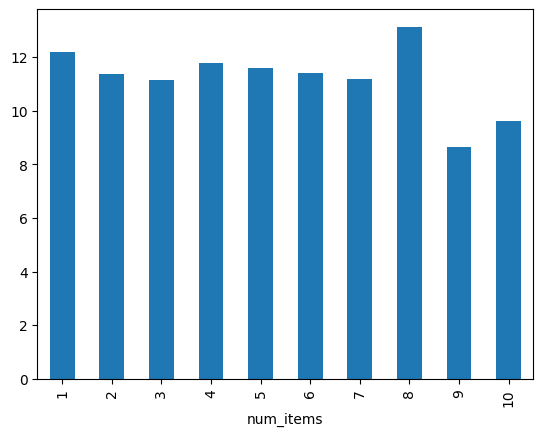

In [41]:
avg_delivery_by_items.head(10).plot(kind="bar")

### Number of items vs delivery time

The analysis shows that the number of items in an order does not significantly affect delivery time.

Most orders, regardless of size, are delivered in around 11–12 days.

This suggests that logistics processes handle multi-item orders similarly to single-item orders.

## Summary

The average delivery time is around 12 days.

Most deliveries occur within 5–15 days, with a small number of extreme delays.

The number of items in an order does not appear to significantly affect delivery time.